import the typing and the framework that helps us design and manage the flow of tasks


In [11]:
%pip install ipython

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
from typing import Dict, TypedDict
from langgraph.graph import StateGraph

In [ ]:
class AgentState(TypedDict):
    message: str



def compliment_node(state: AgentState) -> AgentState:
    """ 
    This nodes adds a compliment message to the agent's state. It can be used as the starting point of a conversation or interaction
    """
    if state["message"] == "Aun":
        state["message"] = "Hey," + state["message"] + " You are amazing my love"
    else:
        state["message"] = "Hey, man You are amazing"
    return state

def farewell_node(state: AgentState) -> AgentState:

    return {"message": "Goodbye! Have a great day!"}


In [25]:
mygraph = StateGraph(AgentState)

mygraph.add_node("complimenter", compliment_node)
mygraph.add_node("farewell", farewell_node)


mygraph.set_entry_point("complimenter")
mygraph.set_finish_point("farewell")

app = mygraph.compile()




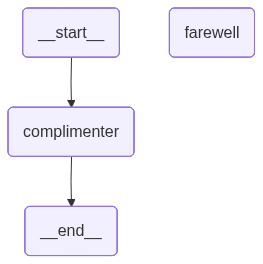

In [26]:
from IPython.display import display, Image
display(Image(app.get_graph().draw_mermaid_png()))

In [27]:
result = app.invoke({"message": "Aun"})

In [28]:
result["message"]

'Hey,AunYou are amazing my love'

In [30]:
from typing import Dict, TypedDict, List
from langgraph.graph import StateGraph


In [ ]:
class AgentState(TypedDict):
    message: str
    name: str
    action: str
    values: List[int]
    result: str
    error: str


In [ ]:
def process_node(state: AgentState) -> AgentState:
    """ 
    This function handles multiple diff inputs
    """
    if state
    state["result"] = f"Hi there, {state['name']}! Your {state['action']} = {sum(state['values'])}"

    return state

In [37]:
graph = StateGraph(AgentState)


graph.add_node("processor", process_node)

graph.set_entry_point("processor")
graph.set_finish_point("processor")

app = graph.compile()


In [42]:
answer = app.invoke({
    "message": "Hello",
    "name": "Aun",
    "action": "sum",
    "values": [1, 2, 3]
})


In [43]:
print(answer)

print(answer["result"])

{'message': 'Hello', 'name': 'Aun', 'action': 'sum', 'values': [1, 2, 3], 'result': 'Hi there, Aun! Your sum = 6'}
Hi there, Aun! Your sum = 6
